# **Run qiskit program using Real IBM Quantum Computers**
### Lin Zhou, January 2025


### Set up service on the backend

In [2]:
import qiskit

qiskit.__version__

'1.4.2'

To use IBM Quantum Computers (backends), we have to use IBM Quantum Computing Runtime

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

These are a couples of ways to setup a service with IBM quantum computing channel. 
- Method 1: using token directly. This is the method  if you use channel for the 1st time. The downside is that the token is visible in the code
- Method 2: retrieve the credentials that was previously save as plain text on the local drive. The benefit of this method is that the token is not needed and shown in the code

Let's use Method 1

In [ ]:
# Method 1. Use token directly
service = QiskitRuntimeService(channel = "ibm_quantum",
                               token ="USE YOUR OWN API KEY")

Let's use Method 2. We will save the credential, then retrieve it. 

In case we have an old credential saved already, the overwrite flag is set to True so we can update the credential

In [ ]:
# Method 2. Save credential
QiskitRuntimeService.save_account(channel="ibm_quantum", 
                                  overwrite=True,
                                  token = "USE YOUR OWN API KEY")

Now we are going to retrieve the credential from the local disk drive. 

Notice that the token is not needed in the command.

In [5]:
# Method 2. Retrieve 
service=QiskitRuntimeService()

At this point, we have successfully initiated a service with the channel. The next step is to specify the which backend we will use. In this example, we will use ibm_brisbane.

It is important that your acount is authorized on the backend. You can do that by checking with quantum.ibm.com.

In [6]:
backend=service.backend(name="ibm_brisbane")

Verify the backend service is successfully set up by checking the number of qubits in the backend

In [7]:
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
)

Name: ibm_brisbane
Version: 2
No. of qubits: 127



Let's get dynamic information of the backend

In [8]:
print(
    backend.qubit_properties(0) # properties of qubit 0
)

QubitProperties(t1=0.00023736364020705798, t2=5.865075292991083e-05, frequency=4721909196.897689)


Let's find out if the backend if operational,and the number of jobs

In [9]:
status = backend.status()
is_operational = status.operational
jobs_in_queue = status.pending_jobs

print(
    f"Operational: {is_operational}\n"
    f"Number of jobs in queue: {jobs_in_queue}")

Operational: True
Number of jobs in queue: 8


## Quantum Computing Sampler

Sampler runs quantum circuits and sample from their classical output registers, shot by shot.

We need a quantum program (aka quantum circuit) to run on the backend. We will use the bell-state circuit. Let's build it.

**Sampler requires measurement gates and map of qubit to clbits**

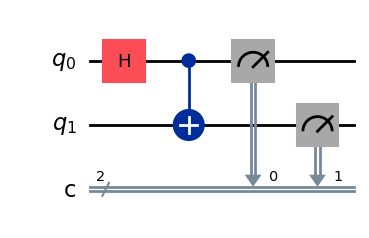

In [10]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])
qc.draw('mpl')

This circuit needs to be normalized (transpiled) to basic gates that the backend is capable of. 

In [11]:
from qiskit import transpile

qc_t = transpile(qc, backend)

To execute a qiskit program on the backend, we need to define a Primitive Unitifed Bloc (PUB). 

The format of PUB is **pub = (circuit, parameter_values, shots)**. Only circuit is required. Others are optionsl.

These are examples of PUB
- pub = (circuit, parameter_values, shots)
- pub = (circuit, parameter_values)
- pub = (circuit, None, shots)

In [13]:
pub = (qc_t,) # No parameter, using default shots

Initiate a sampler and a job

In [14]:
from qiskit_ibm_runtime import SamplerV2

sampler=SamplerV2(backend)

Now we are ready to submit the job to the backend and run it. You have a QPU time quota (10 minutes). Each run will draw down your available QPU allocation. *** ONLY SUBBMIT JOB WHEN YOU ARE ABSOLUTELY READY ***

In [ ]:
# This block run our qiskit program on the backend. 
# Uncomment the next time to make it executable

job = sampler.run(pub,shots=10)

# Print job_id for future reference
job_id=job.job_id()
print(job_id)

#Completed job id 1: cy0yca16vek0008r9tg0
#Completed job id 2: czt8ja1qnmvg008v80s0
#Completed job id 3: cztj9vqrxz8g008ece5g

cztj9vqrxz8g008ece5g


Check job status

In [17]:
job.status()

'DONE'

In [18]:
# Find quantum time used by the job
print(f"Quantum time used by job {job.job_id()} was {job.metrics()['usage']['quantum_seconds']} seconds")


Quantum time used by job cztj9vqrxz8g008ece5g was 1 seconds


The job may take some times to complete. Since I have run this progam before, I will retrieve the result and use it.

In [19]:
job_id = "cy0yca16vek0008r9tg0"
job = service.job(job_id)

Use result() method to extract data

In [20]:
result=job.result()
data=result[0].data
print(data)

DataBin(c=BitArray(<shape=(), num_shots=10, num_bits=2>))


Let's explore the data.

In [22]:
# If measurement gate is created using qc.measure([0,1],[0,1]), use data.c to extract bits
# If measurement gate is created using qc.measure_all, usd data.meas to extract bits
# ref https://quantumcomputing.stackexchange.com/questions/38780/how-to-run-the-qiskit-sampler-after-storing-measurement-results-on-classical-qub

bits=data.c
print("shape",bits.shape)
print("num_bits",bits.num_bits)
print("num_shots", bits.num_shots)
print("array:\n", bits.array)

shape ()
num_bits 2
num_shots 10
array:
 [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [3]
 [0]
 [3]]


The values in the bits.array output represents the measured statevector. The values are uint8 byte ranging from 0 - 255. Statevector is represented by bit strings such as 00, 01, 10, 11. A uint8 value of 3 would be equivalent to a bit string of 11. 

Let's convert uint8 values to bit string values

In [23]:
bitstrings = bits.get_bitstrings()
print(bitstrings)

['00', '00', '00', '00', '00', '00', '00', '11', '00', '11']


Summarize the statevectors using counts() method

In [24]:
counts=bits.get_counts()
print(counts)

{'00': 8, '11': 2}


------ end of Sampler module ------

## Quantum Computing Estimator

Estimators accept combinations of circuits and observables to estimate expectation values of the observables.

*** To use estimator, a quantum circuit can NOT have any measurement gate

The Estimator module is needed.

In [25]:
from qiskit_ibm_runtime import EstimatorV2

Let's buid a the bell state circuit without any measurement gate

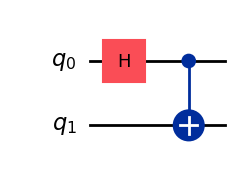

In [26]:
from qiskit import QuantumCircuit

qc=QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

qc.draw('mpl')


Tranpile the circuit. Here we use another way to transpile.

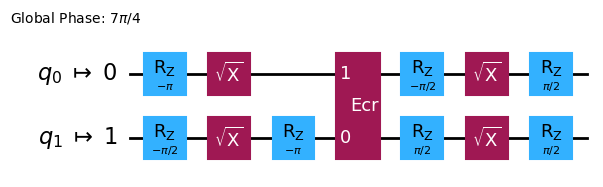

In [29]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pass_manager=generate_preset_pass_manager(optimization_level=1, backend=backend)
qc_transpiled = pass_manager.run(qc)
qc_transpiled.draw("mpl", idle_wires=False)

Set up the observable. Here we use a ZZ gate. It also has to be transpiled.

In [30]:
import qiskit.quantum_info as qi

# Create an observable
obs=qi.SparsePauliOp(["ZZ"])

# Transpile to ISA Observable for intended ISA circuit
isa_obs = obs.apply_layout(qc_transpiled.layout) #ISA = Instruction set architecture

In [31]:
obs_matrix=obs.to_operator()
obs_matrix.draw("latex")

<IPython.core.display.Latex object>

Sertup the Primitive Unified Bloc (PUB). It has the format of **pub = (circuit, observable, parameter_list, shots)**. Only circuit and observable are required.

In [32]:
pub=(qc_transpiled, isa_obs)

Setup estimator instance.

In [33]:
estimator=EstimatorV2(backend)

Execute estimator on the backend. 
** ONLY RUN IT WHEN YOU ARE READY **

In [ ]:
# Uncomment the job line below to submit the job to the backend

job=estimator.run([pub])

# print job id for future reference
job_id=job.job_id()
print(job_id)

#Job ID 1: cy0zhke01rbg008hrmsg

#Job ID 2: czt904rnhqag008sx6h0

#Job ID 3: cztjje1kzhn0008cf070

cztjje1kzhn0008cf070


In [40]:
job.status()

'DONE'

Load results from previous completed job

In [42]:
job_id = "cy0zhke01rbg008hrmsg"
job = service.job(job_id)
result=job.result()

In [41]:
# Find quantum time used by the job
print(f"Quantum time used by job {job.job_id()} was {job.metrics()['usage']['quantum_seconds']} seconds")


Quantum time used by job cztjje1kzhn0008cf070 was 12 seconds


Retrieve data

In [43]:
data=result[0].data
evs = data.evs # expected values
stds = data.stds # Standard deviation
print(f"<zz> = {evs} +- {stds}")

<zz> = 0.9934980494148244 +- 0.02390228234577452


------ End of Estimator ------

Lin Zhou, January 2025